# HW 13 - Introduction to SciPy
ULAB - Physics and Astronomy Division
Due **Sunday, February 16th, 2025 at 11:59 PM** on Gradescope.

------

## 0 Academic Integrity

Please type the following message in the cell below as a comment. Sign with your name.

------

**I certify that I did not use AI tools, such as ChatGPT, to generate or write code for this assignment. All work submitted is my own and reflects my understanding of the material.**

------


In [ ]:
# I certify that I did not use AI tools, such as ChatGPT, to generate or write code for this assignment.
# All work submitted is my own and reflects my understanding of the material.
# Signed, Andrew Kesler

## 1 Simulate a Pendulum
A simple pendulum follows the equation:

$$
\frac{\text{d}^2\theta}{\text{d}t^2} + \frac{g}{L}\sin(\theta) = 0
$$

The goal is to **numerically solve the equation** and compare it to the small-angle approximation.

***Small-Angle Approximation:** a mathematical simplification used in physics when dealing with osciallatory motion, particularly for pendulums and trigonometric funcitons in general.*

Import `numpy`, `matplotlib` and `solve_ivp` in the cell below.

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

Define the acceleration of gravity $g$ (two significant digits is fine) and the length of the pendulum $l$ in the cell below to **1 meter**.

In [7]:
g = 9.81
L = 1.0

Write a **function** called `pendulum` that contain the arguments `t` and `y`. Write out the differential equation. Follow the structure Brianna gave in lecture, it's very similar.

*Hint: The variable domega/dt should be equal to -(g / L) * np.sin(theta)*. I'll let you take care of the rest. 

In [9]:
def pendulum(t, y):
    """
    Computes the derivatives for a pendulum's motion.
    
    Parameters:
    - t : float
        Current time point.
    - y : list of floats
        Current state of the pendulum, where y[0] is the angle theta (in radians)
        and y[1] is the angular velocity omega (in rad/s).
    
    Returns:
    - list of floats
        Derivatives of theta and omega.
    """
    theta, omega = y
    dtheta_dt = omega  # Derivative of theta is omega
    domega_dt = -(g / L) * np.sin(theta)  # Derivative of omega as given
    
    return [dtheta_dt, domega_dt]

Give you equation some initial conditions. Run the cell below.

In [17]:
theta_0 = np.radians(10) # Convert 10 degrees to radians
omega_0 = 0.0 # Initial angular velocity

Solve the differential equation using `solve_ivp`. Set the simulation time to **10 seconds** and the time for evaluation to **10 steps**.

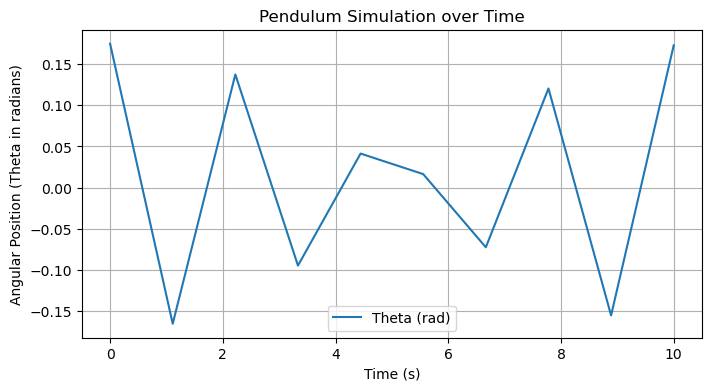

In [20]:
def solve_pendulum(theta_0, omega_0, g, L, t_max, num_steps):
    """
    Solves the differential equation for a pendulum using initial conditions and given parameters.
    
    Parameters:
    - theta_0 : float
        Initial angle in radians.
    - omega_0 : float
        Initial angular velocity in rad/s.
    - g : float
        Acceleration due to gravity in m/s^2.
    - L : float
        Length of the pendulum in meters.
    - t_max : float
        Total time for the simulation in seconds.
    - num_steps : int
        Number of time points for the solver to store the results.
    
    Returns:
    - sol : Bunch object
        Object returned by `solve_ivp` containing times and solution arrays.
    """
    # Define the ODE system
    def pendulum(t, y):
        theta, omega = y
        return [omega, -(g / L) * np.sin(theta)]
    
    # Time span and evaluation points
    t_span = (0, t_max)
    t_eval = np.linspace(*t_span, num_steps)
    
    # Solve the ODE
    sol = solve_ivp(pendulum, t_span, [theta_0, omega_0], t_eval=t_eval, method='RK45')
    
    return sol

# Given parameters
g = 9.81
L = 1.0
t_max = 10  # total simulation time in seconds
num_steps = 10  # number of steps for evaluation

# Solve the pendulum motion
sol = solve_pendulum(theta_0, omega_0, g, L, t_max, num_steps)

# Plot the solution
plt.figure(figsize=(8, 4))
plt.plot(sol.t, sol.y[0], label='Theta (rad)')
plt.title('Pendulum Simulation over Time')
plt.xlabel('Time (s)')
plt.ylabel('Angular Position (Theta in radians)')
plt.grid(True)
plt.legend()
plt.show()

Extrac the **theta** values (`sol.y`) and the **time** values (`sol.t`).

In [23]:
theta_values = sol.y[0]  
time_values = sol.t      

print("Time values:", time_values)
print("Theta values:", theta_values)

Time values: [ 0.          1.11111111  2.22222222  3.33333333  4.44444444  5.55555556
  6.66666667  7.77777778  8.88888889 10.        ]
Theta values: [ 0.17453293 -0.16502944  0.1372768  -0.09451914  0.04132961  0.01640821
 -0.07231679  0.12026021 -0.15495771  0.17260154]


Calculate the theoretical period (aka small-angle approximation).

*Hint: Use `2 * np.pi * np.sqrt(L / g)`.*

In [25]:
theoretical_period = 2 * np.pi * np.sqrt(L / g)

print("Theoretical Period (Small-Angle Approximation):", theoretical_period, "seconds")

Theoretical Period (Small-Angle Approximation): 2.0060666807106475 seconds


Print out the theoretical period (small-angle approximation) to **two** significant digits.

In [28]:
print(f"Theoretical Period (Small-Angle Approximation): {theoretical_period:.2f} seconds")

Theoretical Period (Small-Angle Approximation): 2.01 seconds


Estimate the period from simulation by finding the first zero crossing. Run the cell below.

In [30]:
zero_crossings = np.where(np.diff(np.sign(theta_values)))[0]
if len(zero_crossings) >= 2:
    T_numerical = 2 * (time_values[zero_crossings[1]] - time_values[zero_crossings[0]])
else:
    T_numerical = None

Plot the results in the cell below. Add a **horizontal** line at `x=0`, give it an `x_label` of **Time (s)**, a `y_label` of **Theta (radians)** and a title.

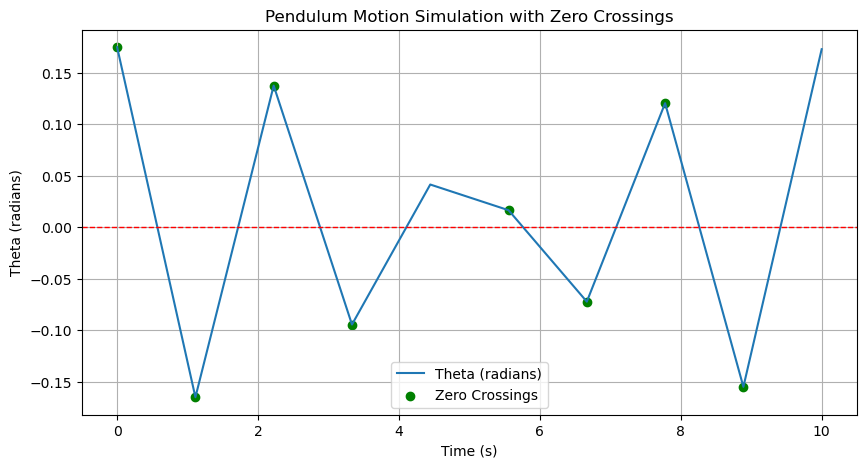

In [32]:
import matplotlib.pyplot as plt

# Plotting theta over time with zero crossing identification
plt.figure(figsize=(10, 5))
plt.plot(time_values, theta_values, label='Theta (radians)')
plt.axhline(0, color='red', linestyle='--', linewidth=1)  # Horizontal line at theta = 0

# Mark zero crossings on the plot
if zero_crossings.size > 0:
    plt.scatter(time_values[zero_crossings], theta_values[zero_crossings], color='green', marker='o', label='Zero Crossings')

plt.xlabel('Time (s)')
plt.ylabel('Theta (radians)')
plt.title('Pendulum Motion Simulation with Zero Crossings')
plt.legend()
plt.grid(True)
plt.show()

Print out the numerical period (what you calculated with scipy) to **four** significant digits.

In [34]:
if T_numerical is not None:
    
    print(f"Numerical Period (Estimated from Simulation): {T_numerical:.4f} seconds")
else:
    print("Numerical Period could not be calculated due to insufficient zero crossings.")

Numerical Period (Estimated from Simulation): 2.2222 seconds


Compare the results between the small-angle approximation and numerical calculation. How well does the approximation match the numerical result?

In [37]:
if T_numerical is not None:
    difference = abs(theoretical_period - T_numerical)
    percent_difference = (difference / theoretical_period) * 100

    print(f"Theoretical Period (Small-Angle Approximation): {theoretical_period:.4f} seconds")
    print(f"Numerical Period (Estimated from Simulation): {T_numerical:.4f} seconds")
    print(f"Difference: {difference:.4f} seconds")
    print(f"Percent Difference: {percent_difference:.2f}%")

    # Provide an assessment of how well the approximation matches the numerical result
    if percent_difference < 5:
        print("The small-angle approximation matches the numerical result very well, with less than 5% difference.")
    elif percent_difference < 10:
        print("The small-angle approximation reasonably matches the numerical result, with less than 10% difference.")
    else:
        print("The small-angle approximation does not closely match the numerical result, with more than 10% difference.")
else:
    print("Numerical Period could not be calculated due to insufficient zero crossings. Comparison not possible.")

Theoretical Period (Small-Angle Approximation): 2.0061 seconds
Numerical Period (Estimated from Simulation): 2.2222 seconds
Difference: 0.2162 seconds
Percent Difference: 10.78%
The small-angle approximation does not closely match the numerical result, with more than 10% difference.


## 2 Using Curve_Fit with Covid-19 Data
Import `pandas` in the cell below.

In [39]:
import pandas as pd

Run the cell below. If that doesn't work, then just **paste** the link into a web browser and it should automatically download. Then you can put the `.csv` file in the same directory as this notebook.

In [41]:
url = "https://covid.ourworldindata.org/data/owid-covid-data.csv"

With the `pandas` function `read_csv`, import the data in the cell below as a dataframe `df`.

In [43]:
import pandas as pd

df = pd.read_csv('owid-covid-data.csv')

print(df.head())

  iso_code continent     location        date  total_cases  new_cases  \
0      AFG      Asia  Afghanistan  2020-01-05          0.0        0.0   
1      AFG      Asia  Afghanistan  2020-01-06          0.0        0.0   
2      AFG      Asia  Afghanistan  2020-01-07          0.0        0.0   
3      AFG      Asia  Afghanistan  2020-01-08          0.0        0.0   
4      AFG      Asia  Afghanistan  2020-01-09          0.0        0.0   

   new_cases_smoothed  total_deaths  new_deaths  new_deaths_smoothed  ...  \
0                 NaN           0.0         0.0                  NaN  ...   
1                 NaN           0.0         0.0                  NaN  ...   
2                 NaN           0.0         0.0                  NaN  ...   
3                 NaN           0.0         0.0                  NaN  ...   
4                 NaN           0.0         0.0                  NaN  ...   

   male_smokers  handwashing_facilities  hospital_beds_per_thousand  \
0           NaN            

Select **United States** as the country and make a new data frame called `df_country` with only this information.

In [45]:
df_country = df[df['location'] == 'United States']

print(df_country.head())

       iso_code      continent       location        date  total_cases  \
403451      USA  North America  United States  2020-01-05          0.0   
403452      USA  North America  United States  2020-01-06          0.0   
403453      USA  North America  United States  2020-01-07          0.0   
403454      USA  North America  United States  2020-01-08          0.0   
403455      USA  North America  United States  2020-01-09          0.0   

        new_cases  new_cases_smoothed  total_deaths  new_deaths  \
403451        0.0                 NaN           0.0         0.0   
403452        0.0                 NaN           0.0         0.0   
403453        0.0                 NaN           0.0         0.0   
403454        0.0                 NaN           0.0         0.0   
403455        0.0                 NaN           0.0         0.0   

        new_deaths_smoothed  ...  male_smokers  handwashing_facilities  \
403451                  NaN  ...          24.6                     NaN   
4034

From your `df_country` dataframe, extract only the relevant columns: **"date"** and **"total_cases"**. 

*Hint: Use `.dropna()` to get rid of the other data.*

In your `df_country` dataframe, add a new column called **"days since start"** and covert the data to numerical days.

*Hint: You can just take the length of your dataframe (`range(len(df_country))`).*

In [47]:
df_country_relevant = df_country[['date', 'total_cases']].dropna()

print(df_country_relevant.head())

df_country_relevant['date'] = pd.to_datetime(df_country_relevant['date'])

df_country_relevant['days since start'] = (df_country_relevant['date'] - df_country_relevant['date'].iloc[0]).dt.days

print(df_country_relevant.head())

              date  total_cases
403451  2020-01-05          0.0
403452  2020-01-06          0.0
403453  2020-01-07          0.0
403454  2020-01-08          0.0
403455  2020-01-09          0.0
             date  total_cases  days since start
403451 2020-01-05          0.0                 0
403452 2020-01-06          0.0                 1
403453 2020-01-07          0.0                 2
403454 2020-01-08          0.0                 3
403455 2020-01-09          0.0                 4


Print the first few rows of your `df_country` dataframe.

In [49]:
print(df_country_relevant.head())

             date  total_cases  days since start
403451 2020-01-05          0.0                 0
403452 2020-01-06          0.0                 1
403453 2020-01-07          0.0                 2
403454 2020-01-08          0.0                 3
403455 2020-01-09          0.0                 4


In the cell below, import `curve_fit`. Make sure to have `numpy` imported in this notebook as well.

In [51]:
import numpy as np
from scipy.optimize import curve_fit

### Some background:
At the beginning of an outbreak, the number of cases follows an exponential growth model:

$$
C(t) = C_0 e^{rt}
$$

where
* $C(t)$ = number of cases at time $t$.
* $C_0$ = initial number of cases.
* $r$ = growth rate.
* $t$ = time in days.

Write a **function** called `exponential_growth` that takes in arguments `t`, `C_0` and `r`. Return the function given above.

In [56]:
import numpy as np  # Ensure numpy is imported

def exponential_growth(t, C_0, r):
    """
    Calculate the number of cases at time t following an exponential growth model.

    Parameters:
    t : float or array-like
        Time in days.
    C_0 : float
        Initial number of cases.
    r : float
        Growth rate.

    Returns:
    float or array-like
        Number of cases at time t.
    """
    return C_0 * np.exp(r * t)

Make a new variable called `days` and another new variable called `cases`. To the `days` variable give it the first 30 rows (your column **"days_since_start"**) and to the `cases` variable give it the first 30 rows (your column **"total_cases"**).

In [58]:
days = df_country_relevant['days since start'].iloc[:30]

cases = df_country_relevant['total_cases'].iloc[:30]

print("Days variable:")
print(days)
print("\nCases variable:")
print(cases)

Days variable:
403451     0
403452     1
403453     2
403454     3
403455     4
403456     5
403457     6
403458     7
403459     8
403460     9
403461    10
403462    11
403463    12
403464    13
403465    14
403466    15
403467    16
403468    17
403469    18
403470    19
403471    20
403472    21
403473    22
403474    23
403475    24
403476    25
403477    26
403478    27
403479    28
403480    29
Name: days since start, dtype: int64

Cases variable:
403451    0.0
403452    0.0
403453    0.0
403454    0.0
403455    0.0
403456    0.0
403457    0.0
403458    0.0
403459    0.0
403460    0.0
403461    0.0
403462    0.0
403463    0.0
403464    0.0
403465    0.0
403466    0.0
403467    0.0
403468    0.0
403469    0.0
403470    0.0
403471    0.0
403472    7.0
403473    7.0
403474    7.0
403475    7.0
403476    7.0
403477    7.0
403478    7.0
403479    9.0
403480    9.0
Name: total_cases, dtype: float64


With `curve_fit` fit the model. Give it the argument `p0 = [1, 0.1]`.

In [60]:
from scipy.optimize import curve_fit

def exponential_growth(t, C_0, r):
    return C_0 * np.exp(r * t)

initial_guesses = [1, 0.1]

params, cov = curve_fit(exponential_growth, days, cases, p0=initial_guesses)

C_0_fitted, r_fitted = params

print("Fitted C_0 (initial number of cases):", C_0_fitted)
print("Fitted r (growth rate):", r_fitted)

Fitted C_0 (initial number of cases): 0.12389530930540793
Fitted r (growth rate): 0.15384247051762281


Extract the best-fit parameters from `popt`. Call them `C0_fit` and `r_fit`.

In [62]:
C0_fit, r_fit = params

print("Best-fit C0 (initial number of cases):", C0_fit)
print("Best-fit r (growth rate):", r_fit)

Best-fit C0 (initial number of cases): 0.12389530930540793
Best-fit r (growth rate): 0.15384247051762281


Print your variables `C0_fit` with **two** significant digits. Print your variables `r_fit` with **four** significant digits.

In [64]:
print(f"Best-fit C0 (initial number of cases): {C0_fit:.2f}")

print(f"Best-fit r (growth rate): {r_fit:.4f}")

Best-fit C0 (initial number of cases): 0.12
Best-fit r (growth rate): 0.1538


Make sure to have `matplotlib` imported. Make a variable called `future_days` give it a numpy range from `0` to `60`. We want to predict up to 60 days.

In [66]:
import matplotlib.pyplot as plt  
import numpy as np  

future_days = np.arange(0, 61)  

print("Range of future days for prediction:", future_days)

Range of future days for prediction: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47
 48 49 50 51 52 53 54 55 56 57 58 59 60]


Make a variable called `predicted_cases` set it equal to your function `exponential_growth` with inputs being `future_days` and your `curve_fit` outputs. 

*Hint: You will want to use `*popt` as your `curve_fit` input.*

In [68]:
predicted_cases = exponential_growth(future_days, *params)

print("First few predicted cases:", predicted_cases[:5])

First few predicted cases: [0.12389531 0.14449998 0.16853136 0.19655933 0.22924856]


**Scater** the variable `cases` as a function of `days`. **Plot** the variable `future_days` as a function of `predicted_cases`. 

Don't forget a label for your x-axis, y-axis, title and legend.

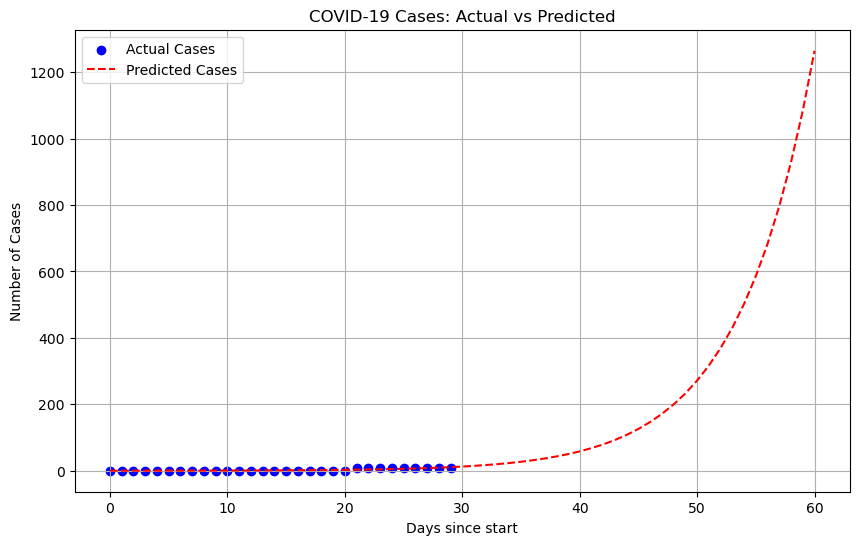

In [70]:
import matplotlib.pyplot as plt  

plt.figure(figsize=(10, 6))

plt.scatter(days, cases, color='blue', label='Actual Cases')

plt.plot(future_days, predicted_cases, color='red', label='Predicted Cases', linestyle='--')

plt.xlabel('Days since start')
plt.ylabel('Number of Cases')
plt.title('COVID-19 Cases: Actual vs Predicted')

plt.legend()

plt.grid(True)
plt.show()

How well does your exponential model fit the actual COVID-19 data? 

In [72]:
from sklearn.metrics import r2_score, mean_squared_error

actual_cases_fitted = exponential_growth(days, *params)

r_squared = r2_score(cases, actual_cases_fitted)
print("R-squared:", r_squared)

rmse = mean_squared_error(cases, actual_cases_fitted, squared=False)
print("Root Mean Square Error (RMSE):", rmse)

R-squared: 0.8022403524854564
Root Mean Square Error (RMSE): 1.5305465988595737


C:\Users\03kes\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


Make another plot but this time to **90 days**.

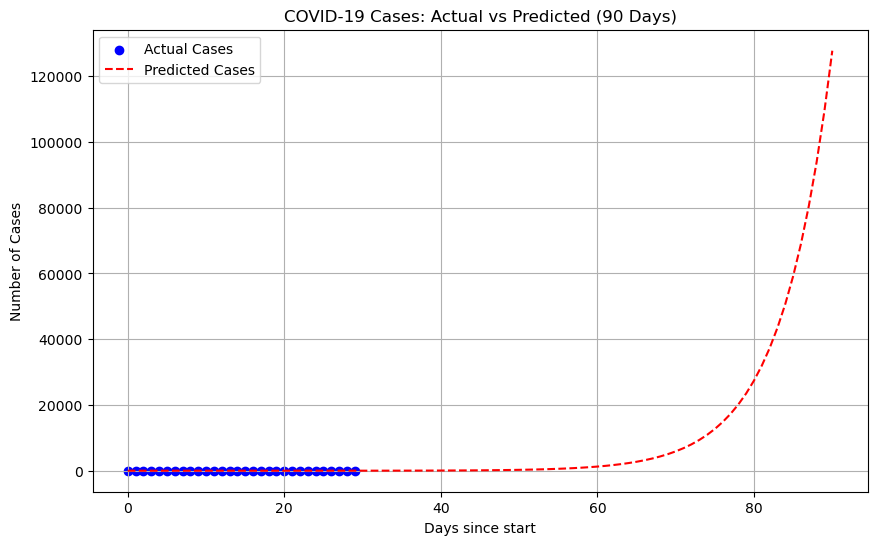

In [74]:
import matplotlib.pyplot as plt
import numpy as np

future_days_90 = np.arange(0, 91) 

predicted_cases_90 = exponential_growth(future_days_90, *params)

plt.figure(figsize=(10, 6))

plt.scatter(days, cases, color='blue', label='Actual Cases')

plt.plot(future_days_90, predicted_cases_90, color='red', label='Predicted Cases', linestyle='--')

plt.xlabel('Days since start')
plt.ylabel('Number of Cases')
plt.title('COVID-19 Cases: Actual vs Predicted (90 Days)')

plt.legend()

plt.grid(True)
plt.show()

What does your model predict the number of cases to be at 87 days? Print in the cell below.

In [76]:
predicted_cases_at_87_days = predicted_cases_90[87]

print(f"Predicted number of COVID-19 cases at 87 days: {predicted_cases_at_87_days:.0f}")

Predicted number of COVID-19 cases at 87 days: 80497


## 3 Seaborn
Use Seaborn to visualize your data, NOT matplotlib. 
1) Go to this website and **pick a dataset that interest you**: https://github.com/mwaskom/seaborn-data
2) Go to this website for documentation: https://seaborn.pydata.org/index.html
3) Import seaborn data (*Hint: You can use the function `sns.load dataset()`. For example, `sns.load dataset('planets')`.*
4) Make a cool plot!
5) With `scipy` add a model to your data. (This can be a different plot.)

            method  number  orbital_period   mass  distance  year
0  Radial Velocity       1         269.300   7.10     77.40  2006
1  Radial Velocity       1         874.774   2.21     56.95  2008
2  Radial Velocity       1         763.000   2.60     19.84  2011
3  Radial Velocity       1         326.030  19.40    110.62  2007
4  Radial Velocity       1         516.220  10.50    119.47  2009


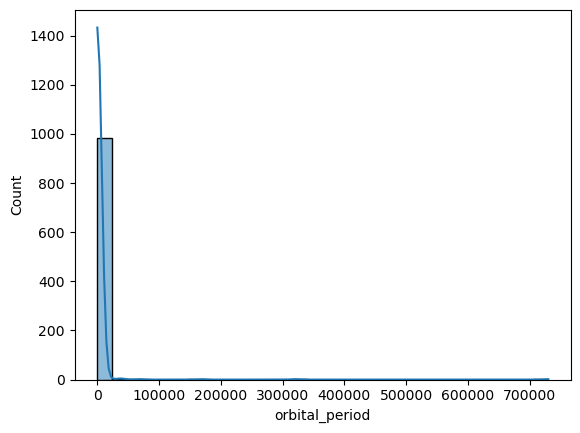

In [89]:
import pandas as pd
import seaborn as sns

file_path = 'C:/Users/03kes/Downloads/planets.csv'

planets = pd.read_csv(file_path)

print(planets.head())

sns.histplot(data=planets, x='orbital_period', bins=30, kde=True)
plt.show()

On it's own branch, submit this notebook to Gradescope! 